<a href="https://colab.research.google.com/github/Dogatwit/Analysis-of-the-Roman-Empire/blob/main/DSF_Project_Help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Coins.csv to Coins (2).csv
Saving Hanson2016_CitiesDatabase_OxREP(Cities).csv to Hanson2016_CitiesDatabase_OxREP(Cities).csv
Saving Harper 2016 Prices Wages and Rents for Roman Egypt, 1-700 - 15.csv to Harper 2016 Prices Wages and Rents for Roman Egypt, 1-700 - 15 (1).csv
Saving roman-emperors.csv to roman-emperors (2).csv


In [ ]:
# --- FILE PATHS ---
EMPERORS_FILE = 'roman-emperors.csv'
WAGES_FILE = 'Harper 2016 Prices Wages and Rents for Roman Egypt, 1-700 - 15.csv'
CITIES_FILE = 'Hanson2016_CitiesDatabase_OxREP(Cities).csv'
COINS_FILE = 'Coins.csv'

In [ ]:
# Loading the data for all questions

def load_all_data():
    # Load Emperors
    emp = pd.read_csv(EMPERORS_FILE, encoding="latin1")
    def get_year(date_str):
        try: return int(str(date_str).split('-')[0])
        except: return np.nan
    emp["start_year"] = emp["Reign Start"].apply(get_year)
    emp["end_year"] = emp["Reign End"].apply(get_year)
    emp.loc[emp['Name'] == 'Augustus', 'start_year'] = -27 # Standardized BC fix

    # Load Wheat
    wheat = pd.read_csv(WAGES_FILE, encoding='latin1')
    wheat = wheat.rename(columns={"Year_Value": "year", wheat.columns[1]: "price"})
    wheat["year"] = pd.to_numeric(wheat["year"], errors="coerce")
    wheat["price"] = pd.to_numeric(wheat["price"], errors="coerce")
    wheat = wheat.dropna(subset=["year", "price"]).copy()

    # Load Cities
    cities = pd.read_csv(CITIES_FILE, encoding='latin1')

    # Load Coins
    coins = pd.read_csv(COINS_FILE, encoding='latin1')

    return emp, wheat, cities, coins

In [ ]:
# Q1 visualisation

def run_q1_q5(emp, wheat):
    print("\n--- Running Q1 & Q5: Wheat Price Analysis ---")
    matched = wheat.merge(emp, how="cross")
    matched = matched[(matched["year"] >= matched["start_year"]) & (matched["year"] <= matched["end_year"])]

    # Q1 Printout
    print(matched[['year', 'Name', 'price']].to_string(index=False))
    matched.to_csv("wheat_emperor_matches.csv", index=False)

    # Q5 Visualization
    plt.figure(figsize=(12, 6))
    plt.scatter(matched['year'], matched['price'], alpha=0.5, color='brown', label='Wheat Price')
    plt.plot(matched.groupby('year')['price'].mean(), color='orange', label='Trendline')
    plt.title('Wheat Price Evolution in Roman Egypt')
    plt.xlabel('Year (AD)')
    plt.ylabel('Price (Artabas)')
    plt.savefig('roman_inflation_chart.png')
    print("Graph saved as 'roman_inflation_chart.png'")

In [ ]:
# Q2 visualisation

def run_q2(emp):
    print("\n--- Running Q2: Emperor Death & Power ---")
    summary = emp.copy().rename(columns={"Succession": "Came_To_Power", "Cause": "Died_By"})
    summary = summary[["Name", "Came_To_Power", "Died_By"]].fillna("Unknown")
    print(summary.to_string(index=False))
    summary.to_csv("emperor_power_and_death.csv", index=False)

In [ ]:
# Q3 visualisation

def run_q3(emp, cities):
    print("\n--- Running Q3: Territory (City) Counts ---")
    cities['Start Date'] = pd.to_numeric(cities['Start Date'], errors='coerce')
    cities['End Date'] = pd.to_numeric(cities['End Date'], errors='coerce')

    def count_active(row):
        mask = (cities['Start Date'] <= row['end_year']) & \
               ((cities['End Date'].isna()) | (cities['End Date'] >= row['start_year']))
        return mask.sum()

    emp['active_cities'] = emp.apply(count_active, axis=1)
    print(emp[['Name', 'active_cities']].to_string(index=False))
    emp[['Name', 'active_cities']].to_csv("q3_territory_output.csv", index=False)

In [ ]:
# Q4 visualisation

def run_q4(coins):
    print("\n--- Running Q4: Coin Material Evolution ---")
    coins['year'] = pd.to_numeric(coins['From Date'], errors='coerce')
    relevant_materials = ['Silver', 'Bronze', 'Copper', 'Billon']
    df_filtered = coins[coins['Material'].isin(relevant_materials)].copy()

    evolution = df_filtered.groupby('Denomination').agg(
        material=('Material', lambda x: x.mode()[0] if not x.empty else "Unknown"),
        earliest_year=('year', 'min'),
        total_count=('Denomination', 'count')
    ).sort_values('earliest_year')

    print(evolution.to_string())
    evolution.to_csv("q4_coin_evolution.csv")


--- Running Q1 & Q5: Wheat Price Analysis ---
 year                  Name  price
 57.0                  Nero  26.67
 61.0                  Nero  23.70
 78.0             Vespasian  18.09
 78.0             Vespasian  29.63
 92.0              Domitian  59.26
 92.0              Domitian  29.63
100.0                Trajan  37.02
103.0                Trajan  40.00
104.0                Trajan  31.73
105.0                Trajan  31.73
106.0                Trajan  21.15
106.0                Trajan  29.63
109.5                Trajan  20.10
111.5                Trajan  31.73
111.5                Trajan  37.02
111.5                Trajan  25.76
111.5                Trajan  42.31
114.0                Trajan  23.70
117.0               Hadrian  26.44
117.0                Trajan  26.44
121.0               Hadrian  35.56
121.5               Hadrian  37.02
125.5               Hadrian  47.60
128.0               Hadrian  31.73
131.5               Hadrian  52.89
131.5               Hadrian  59.26
131.5   

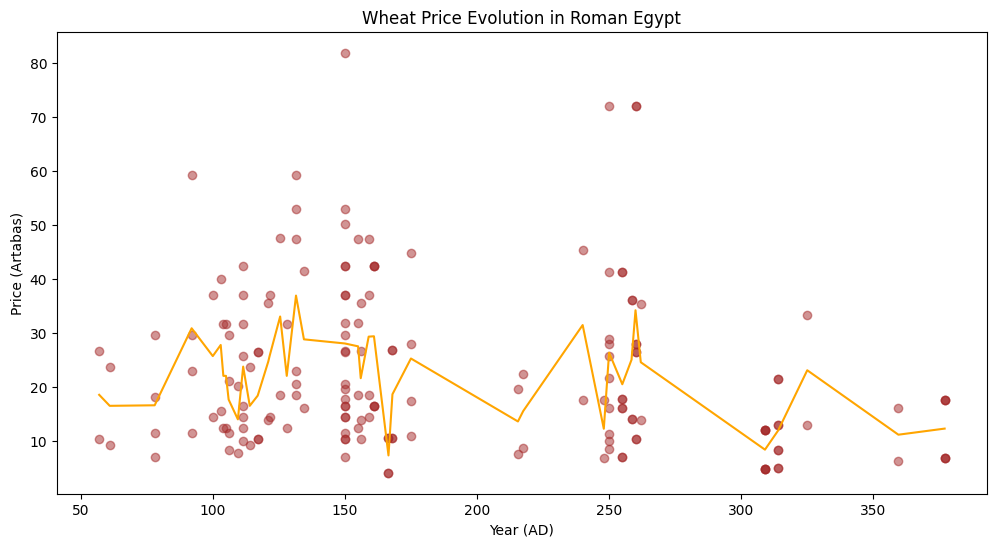

In [ ]:
# Run all visualisations

def main():
    emp, wheat, cities, coins = load_all_data()

    run_q1_q5(emp, wheat)
    run_q2(emp)
    run_q3(emp, cities)
    run_q4(coins)

    print("\nAll analyses complete. Check your folder for CSVs and PNGs.")

if __name__ == "__main__":
    main()

Linear R-squared: 0.0394
Polynomial R-squared: 0.0402
Success! Regression chart saved as 'ml_inflation_results.png'.


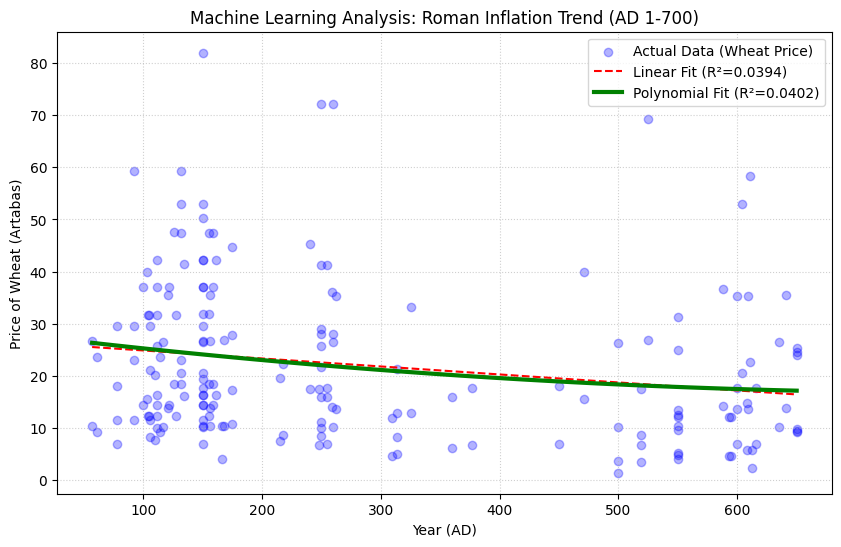

In [ ]:
def run_ml_inflation_analysis():
    # Using 'latin1' to handle the special characters in the CSV
    df = pd.read_csv(WAGES_FILE, encoding='latin1')

    # Identify the year and price columns (using rename to handle long headers)
    df = df.rename(columns={"Year_Value": "year", df.columns[1]: "price"})

    # Ensure columns are numeric and drop rows with missing values (NaN)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["year", "price"])

    X = df[['year']].values
    y = df['price'].values

    lin_model = LinearRegression()
    lin_model.fit(X, y)
    y_lin_pred = lin_model.predict(X)
    lin_r2 = lin_model.score(X, y)

    # This model is better for things like hyperinflation that aren't a straight line
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)

    # Create a smooth line for the polynomial plot
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly_features.transform(X_range)
    y_poly_pred = poly_model.predict(X_range_poly)
    poly_r2 = poly_model.score(X_poly, y)

    plt.figure(figsize=(10, 6))

    # Plot original data points (low alpha helps show density)
    plt.scatter(X, y, color='blue', alpha=0.3, label='Actual Data (Wheat Price)')

    # Plot the Linear Regression line (Red Dash)
    plt.plot(X, y_lin_pred, color='red', linestyle='--', label=f'Linear Fit (R²={lin_r2:.4f})')

    # Plot the Polynomial Regression curve (Green Solid)
    plt.plot(X_range, y_poly_pred, color='green', linewidth=3, label=f'Polynomial Fit (R²={poly_r2:.4f})')

    plt.title('Machine Learning Analysis: Roman Inflation Trend (AD 1-700)')
    plt.xlabel('Year (AD)')
    plt.ylabel('Price of Wheat (Artabas)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # Save the chart for your PowerPoint
    plt.savefig('ml_inflation_results.png')
    print(f"Linear R-squared: {lin_r2:.4f}")
    print(f"Polynomial R-squared: {poly_r2:.4f}")
    print("Success! Regression chart saved as 'ml_inflation_results.png'.")

if __name__ == "__main__":
    run_ml_inflation_analysis()